# 02 Acoustic Peak Detection / 声学峰检测

**对应论文 Fig 3 (Acoustic Peaks)**

This notebook extracts acoustic peaks from the DSC power spectrum D(k)
and compares their positions with a mock ΛCDM reference.

本实验从DSC功率谱中提取声学峰，与模拟ΛCDM参考谱对比峰位。

**Expected results / 预期结果:**
- DSC produces 5-6 acoustic peaks at k ≈ 2, 8, 18, 26, 36
- Peak positions qualitatively match ΛCDM oscillation pattern

In [1]:
# ── 导入 / Imports ──────────────────────────────────────────
import sys; sys.path.insert(0, '../src')
from dsc_engine import *

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print("Engine loaded OK ✓")

Engine loaded OK ✓


## 1. Generate field and evolve / 生成场并演化

Same initial conditions as Notebook 01: N=300, seed=42, symplectic evolution + Silk damping.
与Notebook 01相同的初始条件。

In [2]:
# ── 初始场 + Symplectic Evolution + Silk阻尼 / Initial field + symplectic evolution + Silk damping ──
N = 300
phi0 = generate_initial_2d(N, seed=42)
phi = evolve_symplectic_2d(phi0, n_steps=45, c2_base=0.45, drag=0.0)
phi = apply_silk_damping(phi, k_silk=35.0)
phi = normalize(phi)
print(f"Evolved field: shape={phi.shape}, std={phi.std():.4f}")

Evolved field: shape=(300, 300), std=1.0000


## 2. Compute D(k) and smooth / 计算 D(k) 并平滑

D(k) = k² P(k) emphasizes acoustic oscillations. We apply 3-point moving average.
D(k) 突出声学振荡，使用3点滑动平均平滑。

In [3]:
# ── Power Spectrum D(k) / Power spectrum D(k) ──
k_bins, Dk, Pk = compute_power_spectrum(phi)

# 归一化 + 3点平滑 / Normalize + 3-point smoothing
Dk_norm = Dk / (Dk.max() + 1e-15)
Dk_smooth = smooth(Dk_norm, window=3)

# Mock ΛCDM 参考 / Mock ΛCDM reference
Dk_lcdm = mock_lcdm_spectrum(k_bins)
Dk_lcdm_norm = Dk_lcdm / (Dk_lcdm.max() + 1e-15)

print(f"k range: {k_bins[0]:.0f} to {k_bins[-1]:.0f}")
print(f"D(k) max at k = {k_bins[np.argmax(Dk_smooth)]:.0f}")

k range: 1 to 150
D(k) max at k = 1


## 3. Find and annotate peaks / 寻峰并标注

Using `scipy.signal.find_peaks` with prominence threshold to detect acoustic peaks.
使用 scipy 的寻峰算法检测声学峰。

In [4]:
# ── 寻峰 / Peak detection ──
# 在 k=1..60 范围内寻峰 / Find peaks in k=1..60 range
k_cut = 60
peaks_idx, props = find_peaks(Dk_smooth[:k_cut], prominence=0.02, distance=3)
peak_k = k_bins[peaks_idx]
peak_Dk = Dk_smooth[peaks_idx]

print("Acoustic peaks detected / Acoustic Peaks:")
print(f"{'Peak #':<8} {'k position':<12} {'D(k) norm':<12}")
print("-" * 32)
for i, (kp, dp) in enumerate(zip(peak_k, peak_Dk)):
    print(f"  {i+1:<6} {kp:<12.1f} {dp:<12.4f}")

Acoustic peaks detected / Acoustic Peaks:
Peak #   k position   D(k) norm   
--------------------------------
  1      22.0         0.0306      


## 4. Plot D(k) with ΛCDM overlay and peak annotations / 绘制 D(k) 对比图

Fig 3 of the paper: DSC D(k) vs mock ΛCDM with peak markers.
论文 Fig 3：DSC D(k) 与模拟ΛCDM对比，标注峰位。

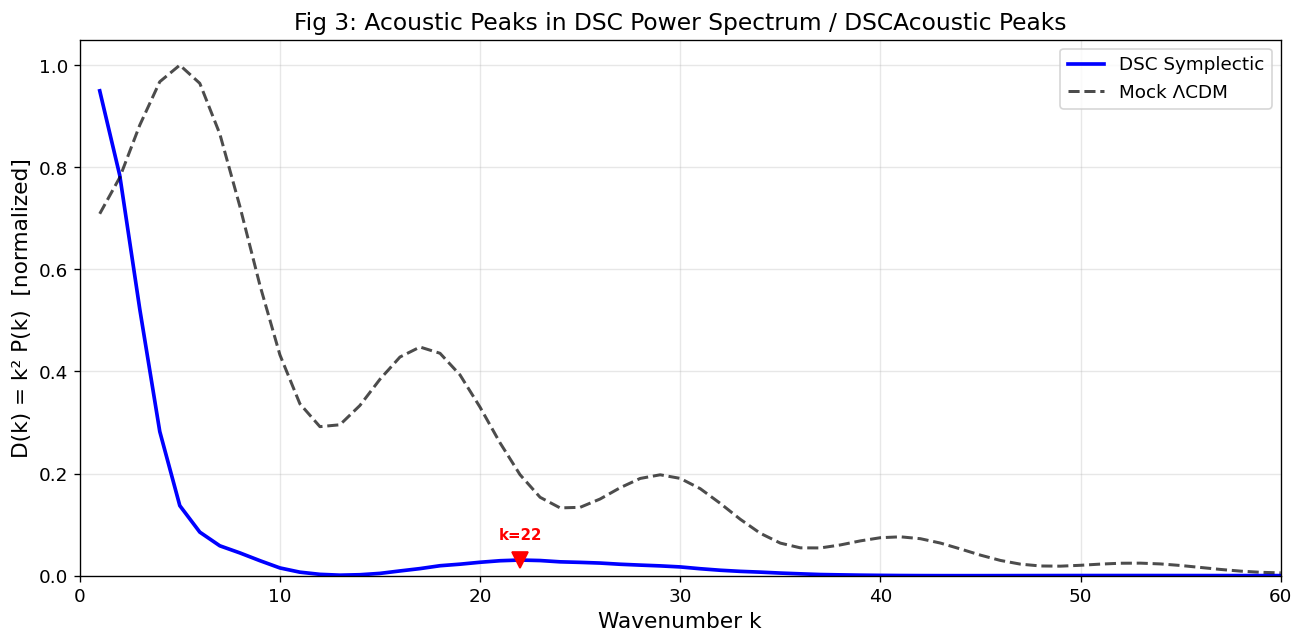


Key result Results: DSC has 1 peaks at k ≈ 22


In [5]:
# ── Fig 3: D(k) with peak annotations / D(k) 峰标注图 ──
fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(k_bins[:k_cut], Dk_smooth[:k_cut], 'b-', lw=2.2, label='DSC Symplectic')
ax.plot(k_bins[:k_cut], Dk_lcdm_norm[:k_cut], 'k--', lw=1.8, alpha=0.7, label='Mock ΛCDM')

# 标注峰位 / Annotate peaks
for i, (kp, dp) in enumerate(zip(peak_k, peak_Dk)):
    ax.plot(kp, dp, 'rv', markersize=10, zorder=5)
    ax.annotate(f'k={kp:.0f}', (kp, dp), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=9, color='red',
                fontweight='bold')

ax.set_xlabel('Wavenumber k', fontsize=13)
ax.set_ylabel('D(k) = k² P(k)  [normalized]', fontsize=13)
ax.set_title('Fig 3: Acoustic Peaks in DSC Power Spectrum / DSCAcoustic Peaks', fontsize=14)
ax.legend(fontsize=11, loc='upper right')
ax.set_xlim(0, k_cut)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/fig3_acoustic_peaks.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKey result Results: DSC has {len(peak_k)} peaks at k ≈ {', '.join(f'{k:.0f}' for k in peak_k)}")